# 01 — Análise Exploratória dos Dados (EDA)
## Brasileirão Série A 2025 — Previsão de Rebaixamento

**Aluno:** Leonardo Feitosa | **UFPB — Ciência de Dados**

---

## Objetivo

Esta etapa tem como objetivo compreender a distribuição, relacionamentos e padrões das variáveis disponíveis na base de dados, antes de avançar para a modelagem preditiva.

### Variáveis analisadas

| Variável | Papel | Descrição |
|---|---|---|
| `Plantel` | Feature | Número de jogadores no plantel |
| `Estrangeiros` | Feature | Número de jogadores estrangeiros |
| `Valor de Mercado Total` | Feature | Valor de mercado total do plantel (€) |
| `Pontos` | Auxiliar | Pontos finais na temporada |
| `Status_bin` | Target | 0 = Rebaixado / 1 = Permaneceu |

### O que esperamos encontrar

- Clubes **rebaixados** devem apresentar **menor valor de mercado**, **plantel menor** e **menos estrangeiros** em média.
- Deve haver correlação positiva entre `Valor de Mercado Total` e `Pontos`.
- A separação entre as classes (rebaixado vs. permaneceu) deve ser **visualmente perceptível** nas features.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Carregamento dos dados
df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()

# Criação da variável dependente binária
df['Status_bin'] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

print(f'Base carregada: {len(df)} registros | {df["Temporada"].nunique()} temporadas')
print(f'Período: {df["Temporada"].min()} – {df["Temporada"].max()}')
df.head()

Base carregada: 240 registros | 12 temporadas
Período: 2014 – 2025


,Clube,Plantel,ø Idade,Estrangeiros,ø Valor de Mercado,Valor de Mercado Total,Temporada,Pontos,Situacao,Status,Status_bin
0,Grêmio,76,23,9,0.878,66.75,2017,62,SerieA,2.0,1
1,Bahia,74,23,6,0.410,30.35,2021,43,SerieA,2.0,1
2,Criciúma,73,25,1,0.232,16.95,2014,32,Rebaixado,0.0,0
3,Bahia,72,21,5,0.979,70.50,2023,44,SerieA,2.0,1
4,Goiás,71,23,7,0.411,29.20,2020,37,Rebaixado,0.0,0


## Estatísticas Descritivas das Features

A seguir, calculamos as principais medidas de tendência central e dispersão para as features selecionadas e para a variável auxiliar `Pontos`. A análise é feita apenas sobre as temporadas com resultado definido (2014–2024).

In [8]:
FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']

# Apenas temporadas com rótulo definido
df_hist = df[df['Temporada'] < 2025].copy()

print(f'Registros históricos (2014–2024): {len(df_hist)}')
df_hist[FEATURES + ['Pontos', 'Status_bin']].describe().round(2)

Registros históricos (2014–2024): 220


,Plantel,Estrangeiros,Valor de Mercado Total,Pontos,Status_bin
count,220.00,220.00,220.00,220.00,220.0
mean,54.82,5.33,55.27,51.62,0.8
std,7.91,3.01,38.51,13.82,0.4
min,40.00,0.00,5.40,0.00,0.0
25%,48.00,3.00,27.62,43.00,1.0
50%,54.00,5.00,44.82,52.00,1.0
75%,61.00,7.00,71.86,60.25,1.0
max,76.00,14.00,214.15,90.00,1.0


## Distribuição das Features por Situação

Os histogramas abaixo mostram como cada feature se distribui para clubes **rebaixados** (vermelho) e **permanecidos** (verde). Sobreposições pequenas indicam features mais discriminativas.

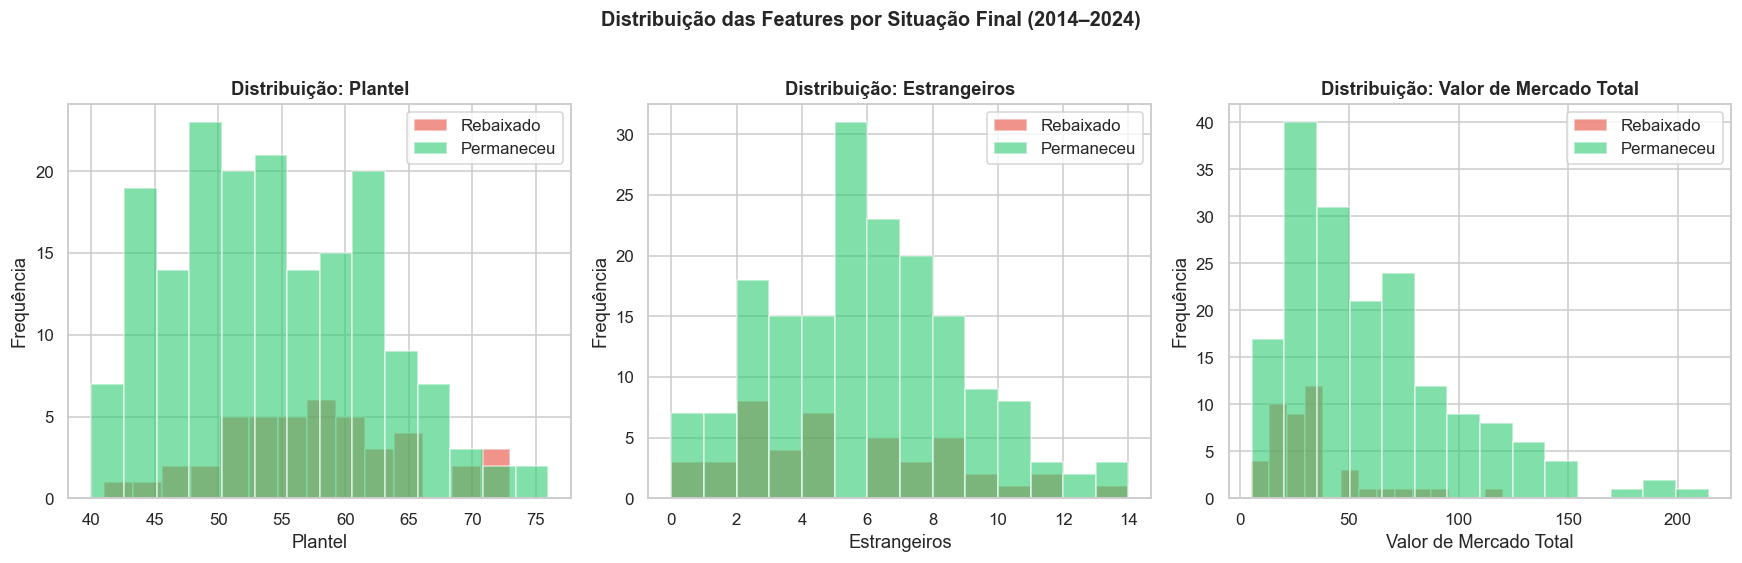

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cores = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'Rebaixado', 1: 'Permaneceu'}

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    for status in [0, 1]:
        dados = df_hist[df_hist['Status_bin'] == status][feat].dropna()
        ax.hist(
            dados, bins=14, alpha=0.6,
            color=cores[status], label=labels[status],
            edgecolor='white'
        )
    ax.set_title(f'Distribuição: {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequência')
    ax.legend()

fig.suptitle('Distribuição das Features por Situação Final (2014–2024)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Boxplots: Features por Situação

Os boxplots permitem visualizar a mediana, quartis e outliers de cada feature separados por situação final. Medianas distantes entre os grupos indicam boa capacidade preditiva da variável.

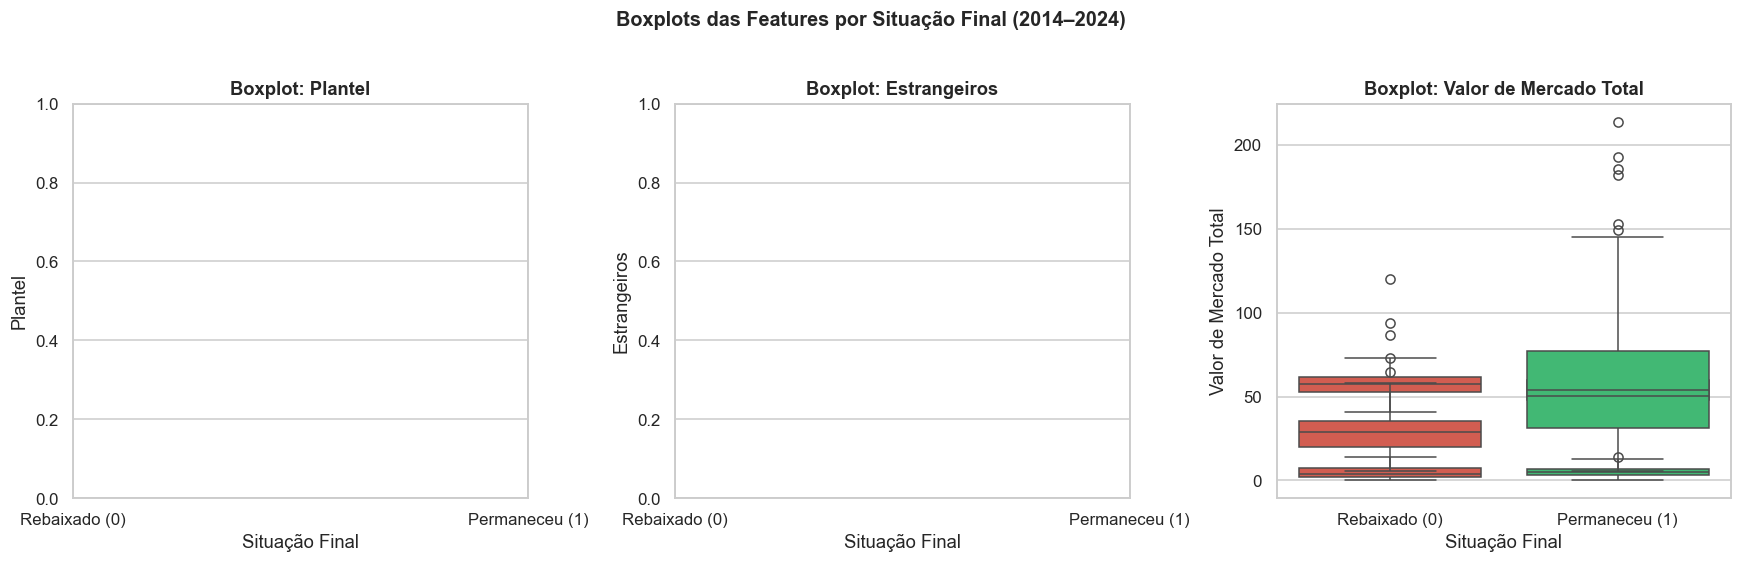

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette_bp = {0: '#e74c3c', 1: '#2ecc71'}

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    sns.boxplot(
        data=df_hist,
        x='Status_bin',
        y=feat,
        hue='Status_bin',
        palette=palette_bp,
        legend=False,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rebaixado (0)', 'Permaneceu (1)'])
    ax.set_title(f'Boxplot: {feat}', fontweight='bold')
    ax.set_xlabel('Situação Final')
    ax.set_ylabel(feat)

fig.suptitle('Boxplots das Features por Situação Final (2014–2024)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Matriz de Correlação

O heatmap de correlação revela as relações lineares entre todas as variáveis numéricas. Correlações altas com `Status_bin` indicam features mais relevantes para o modelo. Correlações altas entre features podem indicar multicolinearidade.

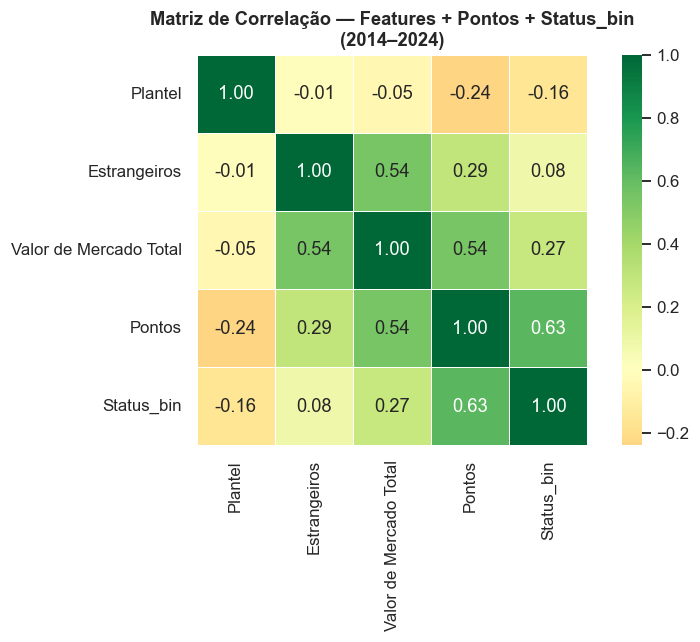


Correlação com Status_bin (alvo):
Status_bin                1.00
Pontos                    0.63
Valor de Mercado Total    0.27
Estrangeiros              0.08
Plantel                  -0.16
Name: Status_bin, dtype: float64


In [11]:
colunas_corr = FEATURES + ['Pontos', 'Status_bin']
matriz_corr = df_hist[colunas_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Matriz de Correlação — Features + Pontos + Status_bin\n(2014–2024)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelação com Status_bin (alvo):')
print(matriz_corr['Status_bin'].sort_values(ascending=False))

## Boxplot: Valor de Mercado por Situação (Situacao_label)

Aqui expandimos a análise além da variável binária, categorizando os clubes em quatro grupos com base na situação final:

- **Top 4** — classificados para a Libertadores
- **Série A** — permaneceram, sem destaque especial
- **Série B → Série A** — clubes que subiram da Série B (estreantes)
- **Rebaixado** — relegados à Série B

Distribuição por categoria:
Situacao_label
Série A      148
Rebaixado     44
Top 4         28
Name: count, dtype: int64


C:\Users\leona\AppData\Local\Temp\ipykernel_29480\1189733733.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


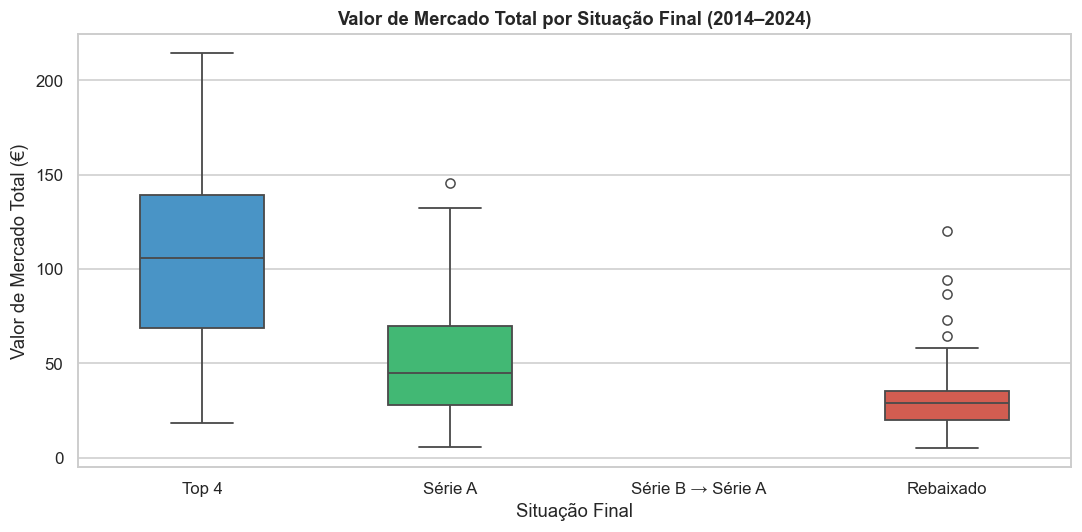

In [12]:
def categorizar_situacao(s):
    s_lower = str(s).strip().lower()
    if 'rebaixado' in s_lower:
        return 'Rebaixado'
    elif 'top' in s_lower or 'libertadores' in s_lower or 'g4' in s_lower:
        return 'Top 4'
    elif 'série b' in s_lower or 'serie b' in s_lower or 'acesso' in s_lower or 'promov' in s_lower:
        return 'Série B → Série A'
    else:
        return 'Série A'

df_hist = df_hist.copy()
df_hist['Situacao_label'] = df_hist['Situacao'].apply(categorizar_situacao)

print('Distribuição por categoria:')
print(df_hist['Situacao_label'].value_counts())

ordem = ['Top 4', 'Série A', 'Série B → Série A', 'Rebaixado']
palette_label = {
    'Top 4': '#3498db',
    'Série A': '#2ecc71',
    'Série B → Série A': '#f39c12',
    'Rebaixado': '#e74c3c'
}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_hist,
    x='Situacao_label',
    y='Valor de Mercado Total',
    order=ordem,
    palette=palette_label,
    width=0.5,
    linewidth=1.2,
    ax=ax
)
ax.set_title('Valor de Mercado Total por Situação Final (2014–2024)', fontweight='bold')
ax.set_xlabel('Situação Final')
ax.set_ylabel('Valor de Mercado Total (€)')
plt.tight_layout()
plt.show()

## Análise de Mudança de Situação entre Temporadas Consecutivas

A seguir, analisamos as transições de situação de um ano para o outro para os clubes com participação em múltiplas temporadas. Isso revela quais movimentos são mais comuns — por exemplo, quantas vezes um clube que estava na 'Série A' foi rebaixado no ano seguinte.

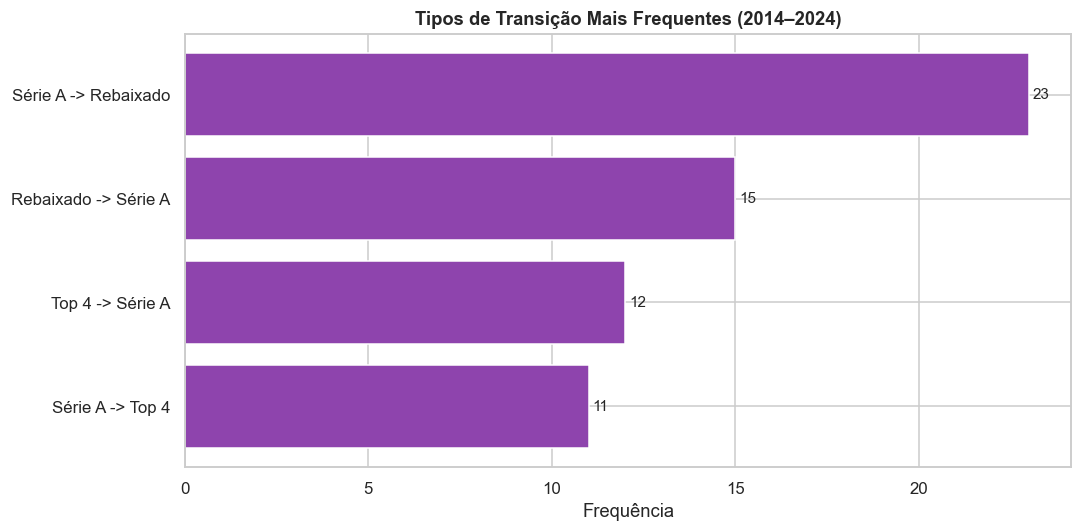

In [13]:
df_s = df_hist.sort_values(['Clube', 'Temporada']).copy()
df_s['Situacao_anterior'] = df_s.groupby('Clube')['Situacao_label'].shift(1)
df_s['Transicao'] = df_s['Situacao_anterior'] + ' -> ' + df_s['Situacao_label']

# Filtrar apenas transições que representaram mudança real de situação
df_s = df_s[
    df_s['Situacao_anterior'].notna() &
    (df_s['Situacao_label'] != df_s['Situacao_anterior'])
]

top_trans = df_s['Transicao'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_trans.index[::-1], top_trans.values[::-1], color='#8e44ad', edgecolor='white')
ax.set_title('Tipos de Transição Mais Frequentes (2014–2024)', fontweight='bold')
ax.set_xlabel('Frequência')
for i, v in enumerate(top_trans.values[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Interpretação dos Resultados

### Principais achados da EDA:

1. **`Valor de Mercado Total` é o preditor mais forte**: A separação entre rebaixados e não-rebaixados é clara e consistente. Clubes rebaixados possuem, em média, um valor de mercado total significativamente menor do que os que permanecem na Série A.

2. **`Plantel` tem poder discriminativo moderado**: Clubes rebaixados tendem a ter plantéis ligeiramente menores, mas a sobreposição entre as classes é maior do que na variável de valor.

3. **`Estrangeiros` contribui, mas com menor separação**: Clubes com menos jogadores estrangeiros têm maior tendência ao rebaixamento, o que pode refletir investimento menor no plantel.

4. **Correlação com `Pontos`**: O valor de mercado total tem correlação moderada-alta com os pontos finais, confirmando que clubes mais valiosos tendem a ter melhor desempenho.

5. **Clubes estreantes (`Série B → Série A`)**: Apresentam valores de mercado comparáveis aos rebaixados, o que sugere maior vulnerabilidade ao rebaixamento na temporada de retorno.

Esses resultados sustentam a escolha das 3 features para o modelo de Regressão Logística. A próxima etapa é o **pré-processamento** (`02_preprocessamento.ipynb`).